### Imports and Setup

In [1]:
import os
from scipy.io import wavfile
import numpy as np
import torch
import torch.nn.functional as F
import librosa
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pyproj as proj
import h5py
import itertools
from tqdm.notebook import tqdm

from whale_gunshot_localization import config
from whale_gunshot_localization.utils.experimental import L2Standardize, MultilaterationOpt, WAVReader, ClipAnalyzer, ParLocalizer
from whale_gunshot_localization.models.tcn_archs import TCNRangeAndClassify
from whale_gunshot_localization.utils.transformations import to_spect, get_image_transform_range_classify

np.random.seed(1234)

Some global setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using the GPU!")
else:
    print("WARNING: Could not find GPU. Using CPU only.")
    
# derive TOSSIT locations relative to the first from the lat/lons
TOSSIT_latlons = np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
pargs = proj.Proj(proj="aeqd", lat_0=TOSSIT_latlons[0, 0], lon_0=TOSSIT_latlons[0, 1], datum="WGS84", units="m")
xs, ys = pargs(TOSSIT_latlons[:,1], TOSSIT_latlons[:,0]) # np.asarray([config['TOSSIT']['TOSSIT_lat'], config['TOSSIT']['TOSSIT_lon']]).T
TOSSIT_locations = np.asarray([-ys, xs]).T

# get image transforms
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))

# root path to experimental data examples
ccb_data_root = os.path.join(*config['dataset']['ccb_data_directory'].split("/")[:-2],"single_examples")

# load model and weights
model = TCNRangeAndClassify(input_size=232,
                            num_channels=7*[368],
                            kernel_size=6,
                            dropout=0.1).to(device)
state_dict = torch.load(os.path.join(config['models']['checkpoints_directories'], config['models']['model_dir'], 'weights_best.pt'),
                       map_location=device)['model_state_dict']
model.load_state_dict(state_dict)
model.eval();

Using the GPU!


### Helper Functions

In [27]:
def circle(r, a, b):
    """
    Produce points on a circle.
    
    Parameters
    ----------
    r : float
        radius of circle
    a : float
        x coordinate of circle center
    b : float
        y coordinate of circle center
        
    Returns
    -------
    (x, y) : Tuple[array-like, array-like]
        lists of x and y points on the circle perimeter
    """
    
    theta = np.linspace(0, 2*np.pi, 100)
    x = r*np.cos(theta) + a
    y = r*np.sin(theta) + b
    return x, y

def localize(r_p, sensors_idx, TOSSIT_locations):
    """
    Use iterative optimization method to localize a source.
    
    Parameters
    ----------
    r_p : np.ndarray
        predicted ranges
    sensors_idx : np.ndarray
        sensors corresponding to r_p values
    TOSSIT_locations : np.ndarray
        locations of sensors of shape N X 2
        
    Returns
    -------
    loc : np.ndarray
        array of location estimate
    """
    ML = MultilaterationOpt(method_thresh=float('inf'))
    # set geometry
    ML.set_map({
        'TOSSIT_locations' : TOSSIT_locations,
        'min_x' : config['scaling']['min_x'],
        'max_x' : config['scaling']['max_x'],
        'min_y' : config['scaling']['min_y'],
        'max_y' : config['scaling']['max_y'],
    })
    _, loc = ML.localize(r_p, sensors_idx)
            
    return loc

def sensor2idx(sensors):
    """
    Convert TOSSIT ID numbers to index in
    the list defined at config['TOSSIT']['ids'].
    
    Parameters
    ----------
    sensors : List[float] or List[int]
        list of sensor IDs
    
    Returns
    -------
    List[Int]
        list of sensor indices
    """
        
    return [config['TOSSIT']['ids'].index(str(int(s))) for s in sensors]

def preprocess_individual_examples(inputs, true_latlon):
    """
    Preprocess individual examples for processing.
    
    Parameters
    ----------
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations associated with the range measurements
    
    Returns
    -------
    inputs : torch.Tensor
        preprocessed spectrograms
    ranges : np.ndarray
        corresponding true ranges
    location_m : np.ndarray
        true source locations
    """

    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    ranges = []
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])
        ranges.extend(np.sqrt(((TOSSIT_locations - location_m[idx,:]) ** 2).sum(axis=1)))
    
    # preprocess
    inputs = preprocessor(inputs)

    return inputs, np.asarray(ranges), location_m

def scan_data(CA, inputs, true_latlon):
    """
    Scans long audio segments from all sensors using model.
    
    Parameters
    ----------
    CA : Clipanalyzer object
        object used to scan audio
    inputs : np.ndarrray
        input time-domain signals of shape, (N X samples/signal)
    true_latlon : np.ndarray
        true locations in lat/lon
        
    Returns
    -------
    rp : List[np.ndarray]
        resulting range predictions on each sensor
    spects : np.ndarray
        preprocessed spectrograms that were detected
    location_m : np.ndarray
        true locations in meters
    """
    
    if len(true_latlon.shape) == 1:
        true_latlon = true_latlon[np.newaxis,:]
    
    # get position and sensor ranges
    location_m = np.zeros(true_latlon.shape)
    for idx, tll in enumerate(true_latlon):
        xt, yt = pargs(tll[1], tll[0])
        yt = -yt
        location_m[idx,:] = np.asarray([[yt, xt]])

    result = CA.process_clips(inputs)

    rp = [x[1] for x in result]
    spects = [x[0] for x in result]
    
    return rp, spects, location_m
    
def plot_range_regression(r_t, r_p):
    """
    Plot true and predicted ranges.
    
    Parameters
    ----------
    r_t : array-like
        true ranges
    r_p : array-like
        predicted ranges
    """
    # get endpoints for identity line
    r_mm = (0, config['scaling']['max_r'] + 5000)
    
    plt.plot(r_t / 1000, r_p / 1000, 'bo', markersize=4)
    plt.plot([r_mm[0] / 1000, r_mm[1] / 1000], [r_mm[0] / 1000, r_mm[1] / 1000], 'r--', label="identity line")
    plt.grid()
    plt.xlabel("True Range [km]")
    plt.ylabel("Predicted Range [km]")
    plt.legend()
    plt.xlim(0, 20)
    plt.ylim(0, 20)
    
def plot_localization(rp, true_loc, sensors, est_loc=None, circles=False):
    """
    Plot true and estimated locations in the context of the TOSSIT sensors.
    
    Parameters
    ----------
    rp : np.ndarray
        ranges
    true_loc :  
    """
    
    if (not isinstance(rp[0], np.ndarray)) and (not isinstance(rp[0], list)):
        rp = [rp]
        
    if (not isinstance(sensors[0], np.ndarray)) and (not isinstance(sensors[0], list)):
        sensors = [sensors]
        
    color_list = ["blue", "red", "green", "purple", "orange", "black"]
    
    # plot TOSSITs
    fliptl = flipy(TOSSIT_locations)
    plt.plot(fliptl[:,1], fliptl[:,0], 'kX', markersize=10, label="TOSSIT", zorder=1)

    # plot predicted location with range circles
    if est_loc is not None:
        if circles:
            for idx_assoc, (assoc_rp, assoc_sensors) in enumerate(zip(rp, sensors)):
                for idx, (r, s) in enumerate(zip(assoc_rp, assoc_sensors)):
                    x, y = circle(r, fliptl[s,1], fliptl[s,0])
                    plt.plot(x, y, '-', linewidth=1, c=color_list[idx_assoc], zorder=0)
        
        if len(est_loc.shape) == 1:
            est_loc = est_loc[np.newaxis, :]
        for idx, el in enumerate(est_loc):
            plt.plot(el[1], el[0], 'ro', label="Location Estimate" if idx == 0 else None, markersize=10, zorder=2)
    
    # plot true location
    if len(true_loc.shape) == 1:
        true_loc = true_loc[np.newaxis, :]
    for idx, tl in enumerate(true_loc):
        plt.plot(tl[1], tl[0], 'g^', label="True Location" if idx == 0 else None, markersize=10, zorder=2)
        
def plot_localization_comparison(true_loc, est_loc=None, est_loc2=None):
    """
    Plot true and estimated locations in the context of the TOSSIT sensors.
    
    Parameters
    ----------
    rp : np.ndarray
        ranges
    true_loc :  
    """
            
    # plot TOSSITs
    fliptl = flipy(TOSSIT_locations) / 1000
    plt.plot(fliptl[:,1], fliptl[:,0], 'kX', markersize=10, label="TOSSIT", zorder=0)
    plt.grid(zorder=-1)
    plt.gca().set_axisbelow(True)

    # plot predicted location with range circles
    if est_loc is not None:
        if len(est_loc.shape) == 1:
            est_loc = est_loc[np.newaxis, :]
        for idx, el in enumerate(est_loc / 1000):
            plt.plot(el[1], el[0], 'o', markerfacecolor='orange', markeredgecolor='black', label="Manual Location Estimate" if idx == 0 else None, markersize=15, zorder=1)
            
        if len(est_loc2.shape) == 1:
            est_loc2 = est_loc2[np.newaxis, :]
        for idx, el in enumerate(est_loc2 / 1000):
            plt.plot(el[1], el[0], '+', markeredgecolor='blue', markeredgewidth=4, label="Automatic Location Estimate" if idx == 0 else None, markersize=15, zorder=1)
    
    # plot true location
    if len(true_loc.shape) == 1:
        true_loc = true_loc[np.newaxis, :]
    for idx, tl in enumerate(true_loc / 1000):
        plt.plot(tl[1], tl[0], 'g^', markeredgecolor='black', label="True Location" if idx == 0 else None, markersize=15, zorder=2)
    
def plot_localization_comparison_grid(true_loc, est_loc, est_loc2, figsize=None, xlim=None, ylim=None, axis_font=None, dim=None, xticks=None, yticks=None):
    if dim:
        rows = dim[0]
        columns = dim[1]
    else:
        rows = int(np.floor(np.sqrt(len(est_loc))));
        columns = int(np.ceil(len(est_loc)/rows));
    fig, axs = plt.subplots(rows,columns,figsize=figsize)
    if not isinstance(axs, np.ndarray):
        axs = np.asarray([[axs]])
    if len(axs.shape) == 1:
        axs = np.asarray([axs])
        
    c = 0
    for i, ax1 in enumerate(axs):
        for j, ax2 in enumerate(ax1):
            if c >= len(est_loc):
                fig.delaxes(ax2)
            else:
                plt.sca(ax2)
                plot_localization_comparison(flipy(true_loc[c]), est_loc=flipy(est_loc[c]), est_loc2=flipy(est_loc2[c]))
                if xticks:
                    ax2.xaxis.set_major_locator(ticker.MultipleLocator(base=xticks))
                if yticks:
                    ax2.yaxis.set_major_locator(ticker.MultipleLocator(base=yticks))
                    
                plt.axis('square')
                if ylim is not None:
                    plt.ylim(*ylim)
                if xlim is not None:
                    plt.xlim(*xlim)

                # logic for axis labels
                if c % columns == 0:
                    plt.ylabel("Y [km]", fontsize=axis_font)
                if c >= (rows - 1) * columns:
                    plt.xlabel("X [km]", fontsize=axis_font)
                if c >= (rows - 2) * columns and c < (rows - 1) * columns:
                    if (i+1)*columns + j >= len(est_loc):
                        plt.xlabel("X [km]", fontsize=axis_font)
                
                if axis_font is not None:
                    plt.yticks(fontsize=axis_font)
                    plt.xticks(fontsize=axis_font)
                
                # logic for axes
                if c % columns != 0:
                    for tick in ax2.yaxis.get_major_ticks():
                        tick.tick1line.set_visible(False)
                        tick.tick2line.set_visible(False)
                        tick.label1.set_visible(False)
                        tick.label2.set_visible(False)
                if (i+1)*columns + j < len(est_loc):
                    for tick in ax2.xaxis.get_major_ticks():
                        tick.tick1line.set_visible(False)
                        tick.tick2line.set_visible(False)
                        tick.label1.set_visible(False)
                        tick.label2.set_visible(False)
                                    
            c += 1
    return fig, axs

def flipy(x):
    xc = x.copy()
    xc[:,0] = -xc[:,0]
    return xc

def selectc(x, idx):
    return [e for i, e in enumerate(x) if i in idx]

### Process Data

Grab the acoustic data

In [7]:
idx_list = [[44], [49], [50], [53], [54], [55], [58], [60], [44, 53], [44, 49], [49, 53], [44, 49, 53]]
oon_idx = [6, 7]
in_s_idx = [0, 1, 2, 3, 4, 5]
in_m_idx = [8, 9, 10, 11]
N = 5

inputs_short = []
sensors_short = []
true_latlon_short = []
associations_short = []
inputs_long = []
sensors_long = []
true_latlon_long = []
for idx in idx_list:
    # load
    with h5py.File(os.path.join("/",ccb_data_root,"gunshots" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
        inputs_short.append(f["/data"][:])
        sensors_short.append(f["/sensors"][:].squeeze())
        true_latlon_short.append(f["/location"][:].T)
        associations_short.append(f["/associations"][:].squeeze())

    try:
        with h5py.File(os.path.join("/",ccb_data_root,"gunshots_long" + "".join([f"_{i}" for i in idx]) + ".h5"), "r") as f:
            inputs_long.append(f["/data"][:])
            sensors_long.append(f["/sensors"][:].squeeze())
            true_latlon_long.append(f["/location"][:].T)
        assert (np.array_equal(true_latlon_short[-1], true_latlon_long[-1])), "True locations are different"
    except:
        raise FileNotFoundError("Corresponding long file is not available")

Process the individual examples and manually localize the data

In [9]:
# preprocess the individual examples
inputs_short_pre = []
ranges_short = []
true_location_m_short = []
for i, ll in zip(inputs_short, true_latlon_short):
    isp, rs, tlms = preprocess_individual_examples(i, ll)
    inputs_short_pre.append(isp)
    ranges_short.append(rs)
    true_location_m_short.append(tlms)

# process with model
outputs_short = []
with torch.set_grad_enabled(False):
    for inp in inputs_short_pre:
        inp = inp.to(device)
        out = model(inp).to('cpu')
        outputs_short.append(out)

# extract results
detections_idx = []
rp_short = []
sensors_idx_short = []
associationsp_short = []
for i, out in enumerate(outputs_short):
    detections_idx.append(np.where((F.softmax(out[:,1:], dim=1)[:,1] >= 0.5) & (ranges_short[i] >= config['scaling']['min_r']) & (ranges_short[i] <= config['scaling']['max_r']))[0])
    
    # get predicted ranges and their corresponding sensor indices and source associations
    rp_short.append((out[detections_idx[i],0] * config['scaling']['max_r']).numpy())
    sensors_idx_short.append(np.asarray(sensor2idx(sensors_short[i][detections_idx[i]])))
    associationsp_short.append(associations_short[i][detections_idx[i]])

# manually localize
loc_short = [np.zeros(tlls.shape) for tlls in true_latlon_short]

#
range_assoc_short = []
sensors_assoc_short = []
for sidx, samp in enumerate(tqdm(associations_short)):
    samp_rp = []
    samp_s = []
    for idx, assoc in enumerate(range(len(np.unique(samp)))):
        rp = rp_short[sidx][associationsp_short[sidx] == assoc]
        s = sensors_idx_short[sidx][associationsp_short[sidx] == assoc]
        
        for n in range(N):
            loc_short[sidx][idx,:] += localize(rp, s, TOSSIT_locations)
        loc_short[sidx][idx,:] /= N
        
        samp_rp.append(rp)
        samp_s.append(s)
                
    range_assoc_short.append(samp_rp)
    sensors_assoc_short.append(samp_s)

  0%|          | 0/12 [00:00<?, ?it/s]

Scan and automatically localize the sources

In [6]:
# get data scanner
data_params = {'fs' : config['signal']['fs'],
               'T' : config['signal']['T'],}
preprocessor = L2Standardize(np.load(config['dataset']['data_directory'] + '/mean_range_classification.npy', allow_pickle=True),
                             np.load(config['dataset']['data_directory'] + '/std_range_classification.npy', allow_pickle=True))
CA = ClipAnalyzer(model, 
                  data_params, 
                  preprocessor,
                  device)

rp_long_list = []
true_location_m_long_list = []
for il, tlll in tqdm(zip(inputs_long, true_latlon_long), total=len(inputs_long)):
    rpl, _, tlml = scan_data(CA, il, tlll)
    rp_long_list.append(rpl)
    true_location_m_long_list.append(tlml)

# make linear lists from detections
rp_linear_list = []
sensors_list = []
for rp_long, true_location_m_long in zip(rp_long_list, true_location_m_long_list):
    rp_linear = []
    sensors = []
    for idx, r in enumerate(rp_long):
        for rr in r:
            rp_linear.append(rr)
            sensors.append(idx)
    rp_linear_list.append(rp_linear)
    sensors_list.append(sensors)

assocs_list, loc_list = [], []
for rp_long in tqdm(rp_long_list):
    assocs_list.append([])
    loc_list.append([])
    for n in range(N):
        L = ParLocalizer(k=5, 
                         multilat=MultilaterationOpt(method_thresh=0.98), 
                         consistency_thresh=500, 
                         TOSSIT_locations=TOSSIT_locations, 
                         min_assoc_size=9)

        assocs, loc = L.adaptive_localize(rp_long)
        assocs_list[-1].append(assocs)
        loc_list[-1].append(loc)

  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

In [14]:
with open('loc_list.npy', 'wb') as f:
    np.save(f, np.array(loc_list, dtype=object), allow_pickle=True)
    
with open('true_location_m_long_list.npy', 'wb') as f:
    np.save(f, np.asarray(true_location_m_long_list, dtype=object), allow_pickle=True)
    
with open('loc_short.npy', 'wb') as f:
    np.save(f, np.asarray(loc_short, dtype=object), allow_pickle=True)
    
with open('true_location_m_short.npy', 'wb') as f:
    np.save(f, np.asarray(true_location_m_short, dtype=object), allow_pickle=True)

In [4]:
loc_list = np.load('loc_list.npy', allow_pickle=True)
true_location_m_long_list = np.load('true_location_m_long_list.npy', allow_pickle=True)
loc_short = np.load('loc_short.npy', allow_pickle=True)
true_location_m_short = np.load('true_location_m_short.npy', allow_pickle=True)

In [11]:
loc_list_sorted = []
true_location_m_short_sorted = []
loc_short_sorted = []
for sub_locs, true_locs, locs_s, true_locs_s in zip(loc_list, true_location_m_long_list, loc_short, true_location_m_short):
    for i, locs in enumerate(sub_locs):
        num_ests = locs.shape[0]

        source_loc_combs = np.asarray(list(map(list, itertools.permutations(locs))))
        tl_short_combs = np.asarray(list(map(list, itertools.permutations(true_locs_s))))
        loc_short_combs = np.asarray(list(map(list, itertools.permutations(locs_s))))

        errors_matrix = np.sqrt(((source_loc_combs[:,:num_ests,:] - true_locs[np.newaxis,:,:]) ** 2).sum(axis=2)).sum(axis=1)
        if i == 0:
            loc_list_sorted.append(source_loc_combs[np.argmin(errors_matrix)])
            true_location_m_short_sorted.append(true_locs_s)
            loc_short_sorted.append(locs_s)
        else:
            loc_list_sorted[-1] += source_loc_combs[np.argmin(errors_matrix)]
    loc_list_sorted[-1] = loc_list_sorted[-1] / N
        # true_location_m_short_sorted.append(tl_short_combs[np.argmin(errors_matrix)])
        # loc_short_sorted.append(loc_short_combs[np.argmin(errors_matrix)])

# get in network examples
true_location_m_short_out = selectc(true_location_m_short_sorted, oon_idx)
loc_short_out = selectc(loc_short_sorted, oon_idx)
loc_list_out = selectc(loc_list_sorted, oon_idx)

true_location_m_short_in_s = selectc(true_location_m_short_sorted, in_s_idx)
loc_short_in_s = selectc(loc_short_sorted, in_s_idx)
loc_list_in_s = selectc(loc_list_sorted, in_s_idx)

true_location_m_short_in_m = selectc(true_location_m_short_sorted, in_m_idx)
loc_short_in_m = selectc(loc_short_sorted, in_m_idx)
loc_list_in_m = selectc(loc_list_sorted, in_m_idx)

true_location_m_short_in_ms = selectc(true_location_m_short_sorted, np.concatenate((in_s_idx, in_m_idx)))
loc_short_in_ms = selectc(loc_short_sorted, np.concatenate((in_s_idx, in_m_idx)))
loc_list_in_ms = selectc(loc_list_sorted, np.concatenate((in_s_idx, in_m_idx)))

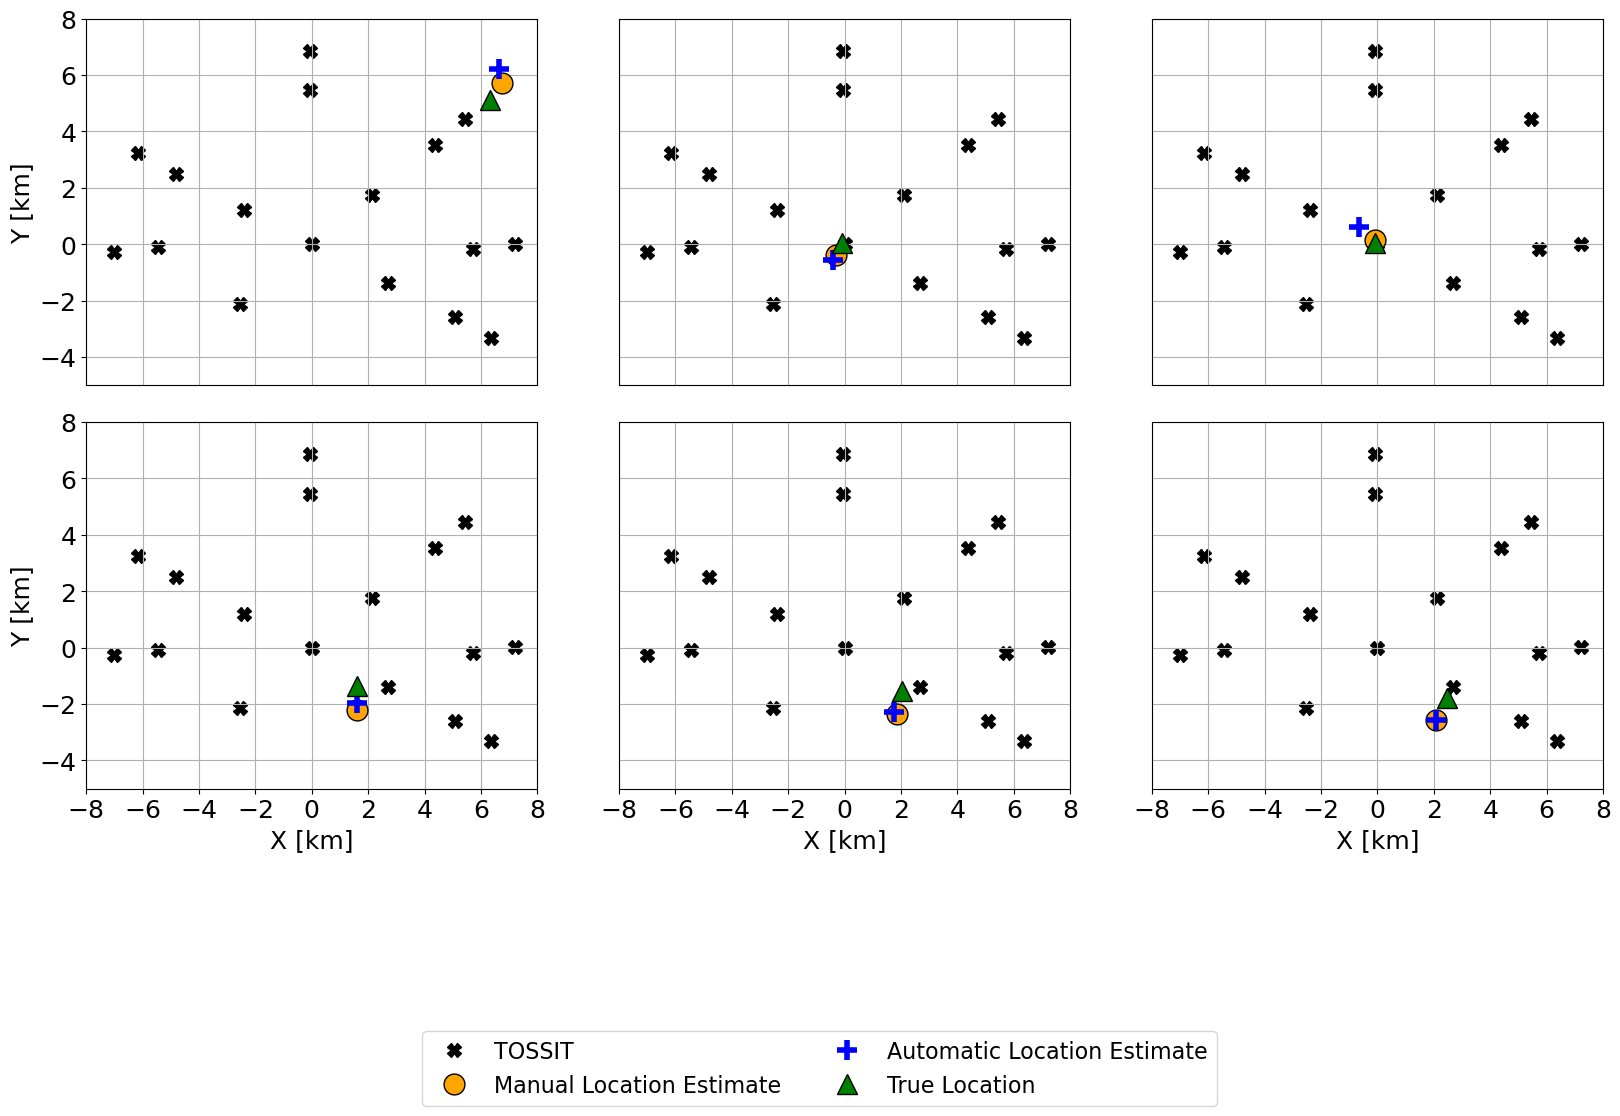

In [28]:
fig, axs = plot_localization_comparison_grid(true_location_m_short_in_s, 
                                             loc_short_in_s, 
                                             loc_list_in_s, 
                                             figsize=(20, 10), 
                                             xlim=(-8, 8), 
                                             ylim=(-5, 8),
                                             axis_font=18)

fig.subplots_adjust(hspace=0.1, wspace=0.1)
h, l = axs[0,1].get_legend_handles_labels()
fig.legend(h, l, loc='center', bbox_to_anchor=(0.5,-0.17), ncol=2, prop={'size': 16})
#fig.tight_layout()
fig.savefig("in_network_s.png")

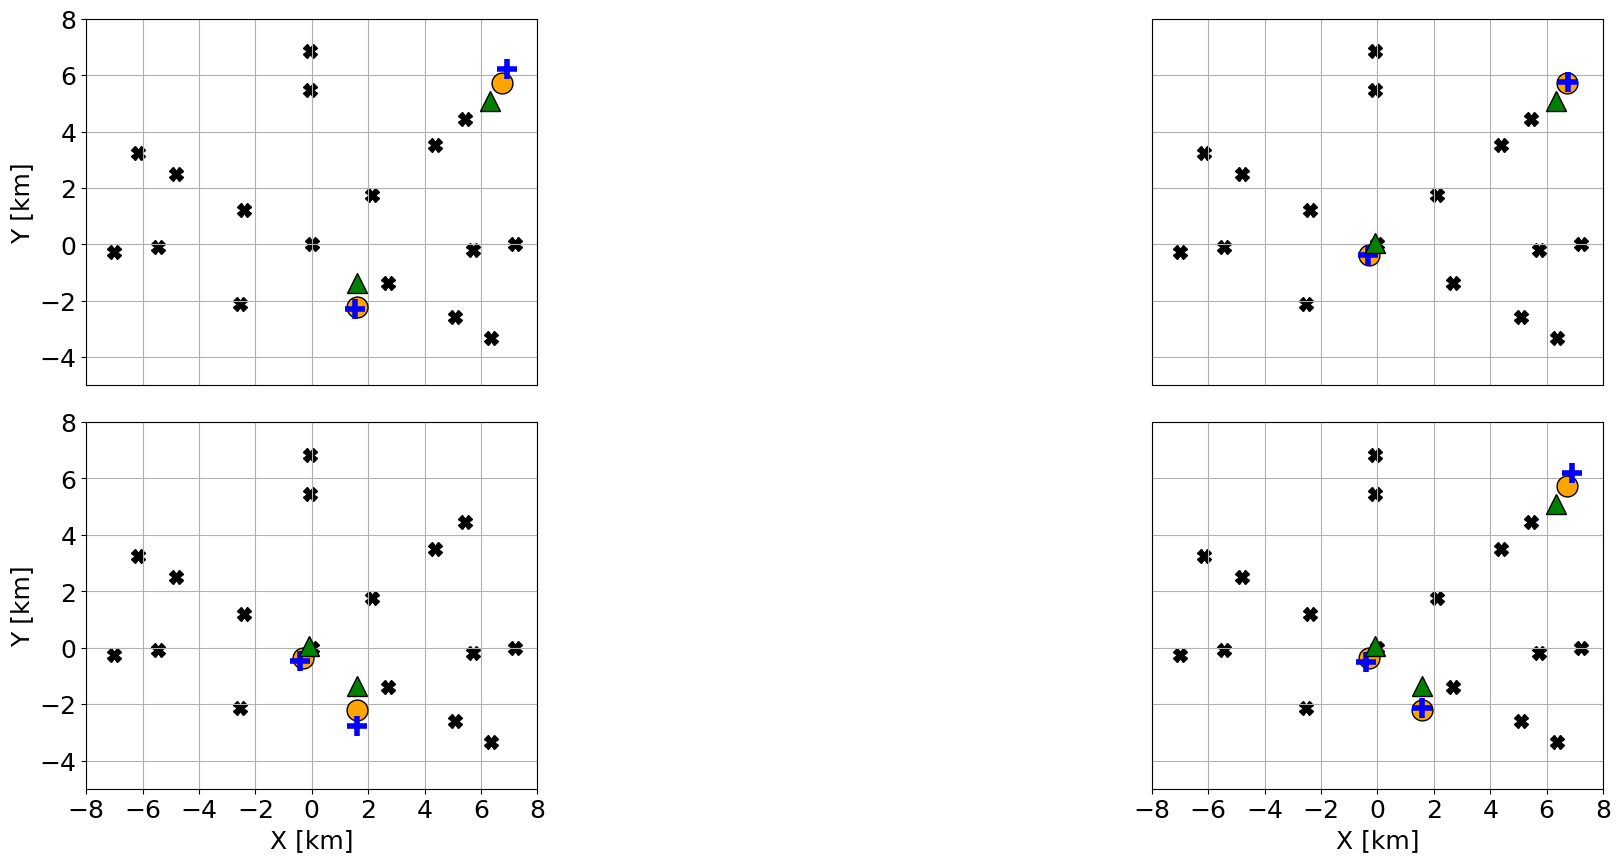

In [29]:
fig, axs = plot_localization_comparison_grid(true_location_m_short_in_m, 
                                             loc_short_in_m, 
                                             loc_list_in_m, 
                                             figsize=(20, 10), 
                                             xlim=(-8, 8), 
                                             ylim=(-5, 8),
                                             axis_font=18)

fig.subplots_adjust(wspace=1.2, hspace=0.1)
# h, l = axs[0,1].get_legend_handles_labels()
# fig.legend(h, l, loc='center', bbox_to_anchor=(0.5,-0.03), ncol=4, prop={'size': 16})
# fig.tight_layout()
fig.savefig("in_network_m.png")

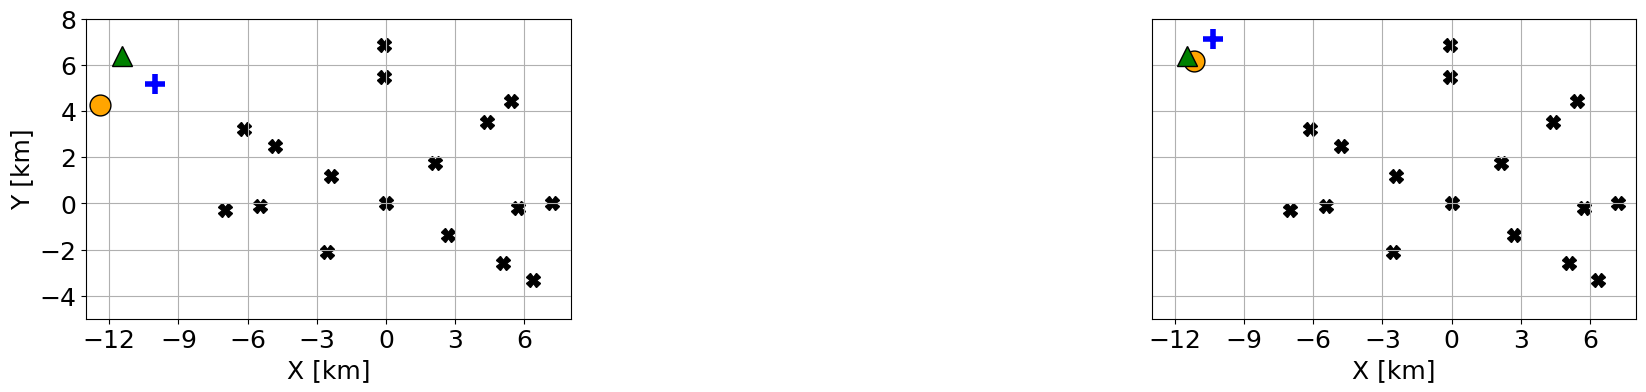

In [30]:
fig, axs = plot_localization_comparison_grid(true_location_m_short_out, 
                                             loc_short_out, 
                                             loc_list_out, 
                                             figsize=(20,10), 
                                             xlim=(-13, 8), 
                                             ylim=(-5, 8),
                                             axis_font=18,
                                             xticks=3)

fig.subplots_adjust(wspace=1.2, hspace=0)
# h, l = axs[0,0].get_legend_handles_labels()
# fig.legend(h, l, loc='center', bbox_to_anchor=(0.5,0.3), ncol=4, prop={'size': 16})
# fig.tight_layout()
fig.savefig("out_of_network.png")

In [32]:
print("ALL\n")
print("statistics (automatic)")
print("----------------------")
errors = np.sqrt(((np.concatenate(loc_list_sorted) - np.concatenate(true_location_m_long_list)) ** 2).sum(axis=1))
print("All Errors: ", errors)
print("Errors σ: ", np.around(np.std(errors), 2), "m")
print("RMSE: ", np.around(np.sqrt((errors ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors.mean(), 2), "m\n")

print("statistics (manual)")
print("-------------------")
errors_ood = np.sqrt(((np.concatenate(true_location_m_short_sorted) - np.concatenate(loc_short_sorted)) ** 2).sum(axis=1))
print("All Errors: ", errors_ood)
print("Errors σ: ", np.around(np.std(errors_ood), 2))
print("RMSE: ", np.around(np.sqrt((errors_ood ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors_ood.mean(), 2), "m")

ALL

statistics (automatic)
----------------------
All Errors:  [1140.20519527  687.62525823  801.66193444  593.45939824  795.32957145
  866.07644856 1896.00533967 1337.48509706 1256.83930212  923.89222833
  772.70548643  500.97209836  605.43150843 1418.10337038 1226.03621307
  636.79896818  766.4073431 ]
Errors σ:  360.03 m
RMSE:  1020.06 m
MAE:  954.41 m

statistics (manual)
-------------------
All Errors:  [ 746.09461558  473.54249667  129.28464199  846.28961839  818.65999708
  873.05725461 2331.5277359   355.36498169  746.09461558  846.28961839
  746.09461558  473.54249667  473.54249667  846.28961839  746.09461558
  473.54249667  846.28961839]
Errors σ:  447.54
RMSE:  874.47 m
MAE:  751.27 m


In [35]:
print("OUT OF NETWORK\n")
print("statistics (automatic)")
print("----------------------")
errors = np.sqrt(((np.concatenate(selectc(loc_list_sorted, oon_idx)) - np.concatenate(selectc(true_location_m_long_list, oon_idx))) ** 2).sum(axis=1))
print("All Errors: ", errors)
print("Errors σ: ", np.around(np.std(errors), 2), "m")
print("RMSE: ", np.around(np.sqrt((errors ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors.mean(), 2), "m\n")

print("statistics (manual)")
print("-------------------")
errors_ood = np.sqrt(((np.concatenate(selectc(true_location_m_short_sorted, oon_idx)) - np.concatenate(selectc(loc_short_sorted, oon_idx))) ** 2).sum(axis=1))
print("All Errors: ", errors_ood)
print("Errors σ: ", np.around(np.std(errors_ood), 2))
print("RMSE: ", np.around(np.sqrt((errors_ood ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors_ood.mean(), 2), "m")

OUT OF NETWORK

statistics (automatic)
----------------------
All Errors:  [1896.00533967 1337.48509706]
Errors σ:  279.26 m
RMSE:  1640.69 m
MAE:  1616.75 m

statistics (manual)
-------------------
All Errors:  [2331.5277359   355.36498169]
Errors σ:  988.08
RMSE:  1667.68 m
MAE:  1343.45 m


In [ ]:
print("IN NETWORK\n")
print("statistics (automatic)")
print("----------------------")
errors = np.sqrt(((np.concatenate(selectc(loc_list_sorted, np.concatenate((in_s_idx, in_m_idx)))) - np.concatenate(selectc(true_location_m_long_list, np.concatenate((in_s_idx, in_m_idx))))) ** 2).sum(axis=1))
print("All Errors: ", errors)
print("Errors σ: ", np.around(np.std(errors), 2), "m")
print("RMSE: ", np.around(np.sqrt((errors ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors.mean(), 2), "m\n")

print("statistics (manual)")
print("-------------------")
errors_ood = np.sqrt(((np.concatenate(selectc(true_location_m_short_sorted, np.concatenate((in_s_idx, in_m_idx)))) - np.concatenate(selectc(loc_short_sorted, np.concatenate((in_s_idx, in_m_idx))))) ** 2).sum(axis=1))
print("All Errors: ", errors_ood)
print("Errors σ: ", np.around(np.std(errors_ood), 2))
print("RMSE: ", np.around(np.sqrt((errors_ood ** 2).mean()), 2), "m")
print("MAE: ", np.around(errors_ood.mean(), 2), "m")